In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from transformers import create_optimizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

df = pd.read_csv("/content/drive/MyDrive/BenglaDataset14k.csv")

print("Before cleaning:", len(df))
df = df.dropna().drop_duplicates()
print("After cleaning NaN & duplicates:", len(df))
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['text'])
y = df['label']

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)               # URL বাদ দাও
    text = re.sub(r"<.*?>", "", text)                 # HTML ট্যাগ বাদ দাও
    text = re.sub(r"[^ঀ-৿a-zA-Z0-9\s]", " ", text)   # বাংলা/ইংরেজি ছাড়া বাদ
    text = re.sub(r"\s+", " ", text).strip()          # অতিরিক্ত স্পেস সরাও
    return text

df['text'] = df['text'].apply(clean_text)


vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['text'])
y = df['label']




# 6. Split Train-Test

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 7. Get back original texts for BERT

# এখানে আমরা X_resampled এর index ব্যবহার করে আবার text পাই


train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Final train size:", len(train_texts))
print("Final test size:", len(test_texts))
print("Label distribution:\n", df['label'].value_counts())



Before cleaning: 13951
After cleaning NaN & duplicates: 13951
Final train size: 11160
Final test size: 2791
Label distribution:
 label
0    7000
1    6951
Name: count, dtype: int64


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report



In [6]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)
test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    use_safetensors=False
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/1.08G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
from transformers import create_optimizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# 10. Load BERT Model

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    use_safetensors=False
)

# 11. Create Optimizer (Fixed)

batch_size = 16
epochs = 5
num_train_steps = (len(train_texts) // batch_size) * epochs
num_warmup_steps = int(0.1 * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=2e-5,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=0.01
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


# 12. Callbacks

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1
)


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    np.array(train_labels)
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    np.array(test_labels)
)).batch(16)


In [9]:
# ==============================
# 13. Train Model (No Callbacks)
# ==============================
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

# ==============================
# 14. Evaluate Model
# ==============================
# Predictions
preds = model.predict(test_dataset).logits
y_pred = np.argmax(preds, axis=1)

# Accuracy & Report
from sklearn.metrics import classification_report, accuracy_score
print("\nAccuracy:", accuracy_score(test_labels, y_pred))
print("\nClassification Report:\n", classification_report(test_labels, y_pred))

# ==============================
# 15. Save Model
# ==============================
model.save_pretrained("multilingual_bert_fake_news_model")
tokenizer.save_pretrained("multilingual_bert_fake_news_model")

print("\n✅ Model training complete and saved successfully!")


Epoch 1/5
698/698 [==============================] - 424s 532ms/step - loss: 0.2670 - accuracy: 0.8697 - val_loss: 0.1310 - val_accuracy: 0.9452
Epoch 2/5
698/698 [==============================] - 371s 531ms/step - loss: 0.1110 - accuracy: 0.9561 - val_loss: 0.1501 - val_accuracy: 0.9463
Epoch 3/5
698/698 [==============================] - 364s 522ms/step - loss: 0.0609 - accuracy: 0.9784 - val_loss: 0.1594 - val_accuracy: 0.9531
Epoch 4/5
698/698 [==============================] - 363s 520ms/step - loss: 0.0259 - accuracy: 0.9914 - val_loss: 0.2037 - val_accuracy: 0.9549
Epoch 5/5
175/175 [==============================] - 28s 145ms/step

Accuracy: 0.9541383016839843

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      1400
           1       0.96      0.95      0.95      1391

    accuracy                           0.95      2791
   macro avg       0.95      0.95      0.95      2791
weighted avg       0.95  

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Predict validation/test dataset
preds = model.predict(test_dataset).logits
y_pred = np.argmax(preds, axis=1)

# Validation score
val_acc = accuracy_score(test_labels, y_pred)
print("Validation Accuracy:", val_acc)

# Optional: detailed report
print("\nClassification Report:\n", classification_report(test_labels, y_pred))


175/175 [==============================] - 26s 146ms/step
Validation Accuracy: 0.9541383016839843

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      1400
           1       0.96      0.95      0.95      1391

    accuracy                           0.95      2791
   macro avg       0.95      0.95      0.95      2791
weighted avg       0.95      0.95      0.95      2791



In [13]:


# ==============================
# 1. Load Trained Model & Tokenizer
# ==============================
model_path = "multilingual_bert_fake_news_model"  # আগের saved model folder
model = TFAutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# ==============================
# 2. Define text to predict
# ==============================
texts = [
    '''
    গত ৫ আগস্ট আওয়ামী লীগ সরকারের পতনের পর ভবনটিতে আগুন লাগিয়ে দেওয়া হয়েছিল।
    এরপর আগস্ট মাসজুড়ে চলে লুটপাট। কেবল এই ভবনই নয়, রাজধানীর তেঁজগাওয়ে ঢাকা জেলা আওয়ামী লীগ কার্যালয়
    ও ধানমন্ডিতে আওয়ামী লীগ সভাপতির কার্যালয়েও আগুন জ্বালিয়ে দেওয়া হয়।
    সেখান থেকেও মালামাল লুট করে নেওয়া হয়। তখন থেকে এই তিন ভবন অনেকটা পরিত্যক্ত অবস্থায় পড়ে আছে।
    '''
]

# ==============================
# 3. Tokenize the text
# ==============================
inputs = tokenizer(texts, return_tensors="tf", truncation=True, padding=True, max_length=128)

# ==============================
# 4. Get prediction
# ==============================
outputs = model(inputs)
probs = tf.nn.softmax(outputs.logits, axis=1).numpy()
pred_labels = np.argmax(probs, axis=1)

# ==============================
# 5. Show results
# ==============================
for text, label, prob in zip(texts, pred_labels, probs):
    print("Text:", text)
    print("Predicted Label:", "Fake" if label == 0 else "Real")
    print("Confidence:", prob[label])
    print("-"*50)


Some layers from the model checkpoint at multilingual_bert_fake_news_model were not used when initializing TFBertForSequenceClassification: ['dropout_75']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at multilingual_bert_fake_news_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.
The tokenizer you are loading from 'multili

Text: 
    গত ৫ আগস্ট আওয়ামী লীগ সরকারের পতনের পর ভবনটিতে আগুন লাগিয়ে দেওয়া হয়েছিল।
    এরপর আগস্ট মাসজুড়ে চলে লুটপাট। কেবল এই ভবনই নয়, রাজধানীর তেঁজগাওয়ে ঢাকা জেলা আওয়ামী লীগ কার্যালয়
    ও ধানমন্ডিতে আওয়ামী লীগ সভাপতির কার্যালয়েও আগুন জ্বালিয়ে দেওয়া হয়।
    সেখান থেকেও মালামাল লুট করে নেওয়া হয়। তখন থেকে এই তিন ভবন অনেকটা পরিত্যক্ত অবস্থায় পড়ে আছে।
    
Predicted Label: Real
Confidence: 0.5287667
--------------------------------------------------


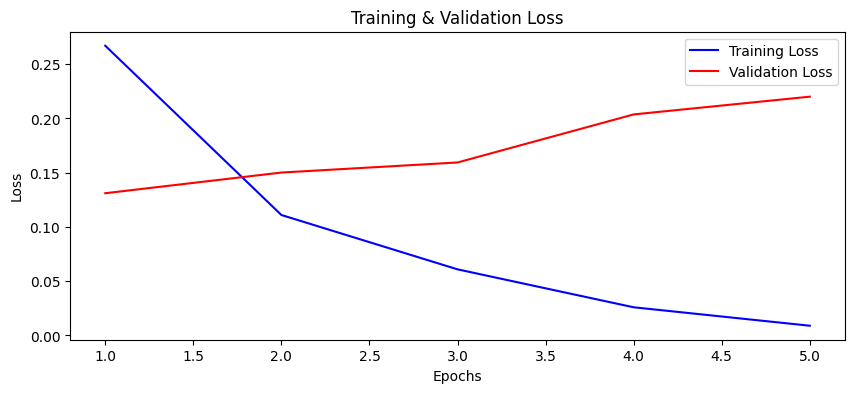

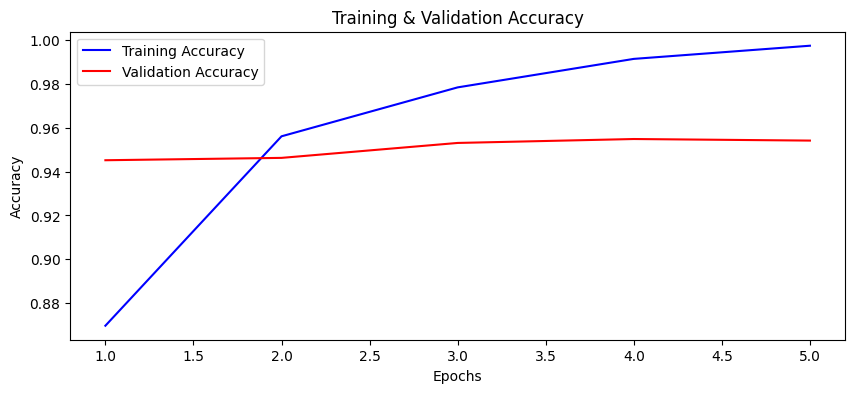

In [14]:

import matplotlib.pyplot as plt

# Training history থেকে metrics নাও
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

# =========================
# 1. Loss Plot
# =========================
plt.figure(figsize=(10,4))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# =========================
# 2. Accuracy Plot
# =========================
plt.figure(figsize=(10,4))
plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
!zip -r multilingual_bert_fake_news_model.zip multilingual_bert_fake_news_model


  adding: multilingual_bert_fake_news_model/ (stored 0%)
  adding: multilingual_bert_fake_news_model/special_tokens_map.json (deflated 42%)
  adding: multilingual_bert_fake_news_model/config.json (deflated 53%)
  adding: multilingual_bert_fake_news_model/vocab.txt (deflated 45%)
  adding: multilingual_bert_fake_news_model/tokenizer.json (deflated 67%)
  adding: multilingual_bert_fake_news_model/tf_model.h5 (deflated 7%)
  adding: multilingual_bert_fake_news_model/tokenizer_config.json (deflated 75%)


In [ ]:
!zip -r multilingual_bert_fake_news_model.zip multilingual_bert_fake_news_model


updating: multilingual_bert_fake_news_model/ (stored 0%)
updating: multilingual_bert_fake_news_model/special_tokens_map.json (deflated 42%)
updating: multilingual_bert_fake_news_model/config.json (deflated 53%)
updating: multilingual_bert_fake_news_model/vocab.txt (deflated 45%)
updating: multilingual_bert_fake_news_model/tokenizer.json (deflated 67%)
updating: multilingual_bert_fake_news_model/tf_model.h5 (deflated 7%)
updating: multilingual_bert_fake_news_model/tokenizer_config.json (deflated 75%)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp multilingual_bert_fake_news_model.zip /content/drive/MyDrive/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle
import joblib


joblib.dump(model, "model.joblib")


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


['model.joblib']

In [ ]:
from google.colab import files
files.download("multilingual_bert_fake_news_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Removed problematic pickle.dump. Model is already saved using model.save_pretrained() in cell _Zik9PQJ9GOs.
# If you need to load the model, use TFAutoModelForSequenceClassification.from_pretrained("multilingual_bert_fake_news_model")

In [ ]:


# ==============================
# 1. Load Trained Model & Tokenizer
# ==============================
model_path = "multilingual_bert_fake_news_model"  # আগের saved model folder
model = TFAutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# ==============================
# 2. Define text to predict
# ==============================
texts = [
    '''ডিএমপির ডিবির প্রধান বলেন, গতকাল রাতে ফারুক, রবিন, শামীম ও রুবেলকে নরসিংদী থেকে গ্রেপ্তার করা হয়। হত্যার পর তাঁরা ঢাকা থেকে সিলেট হয়ে ভারতে যাওয়ার চেষ্টা করেছিলেন। কিন্তু সিলেট থেকে ভারত প্রবেশ করতে না পেরে তাঁরা সাতক্ষীরা হয়ে সীমান্ত পার হওয়ার পরিকল্পনা করছিলেন। সিলেট থেকে আসার পথে নরসিংদীতে তাঁদের গ্রেপ্তার করা হয়।

শফিকুল ইসলাম বলেন, হত্যার পর ফারুক ও রবিন তাঁদের ব্যবহৃত অস্ত্রসহ অব্যবহৃত গুলি রনির নির্দেশে রুবেলের হেফাজতে রাখেন। রুবেল ভাড়ায় গাড়ির ব্যবসা করেন। পরে রুবেল অস্ত্র ও গুলি ইউসুফের হেফাজতে দেন। রুবেলকে ধরার পর তাঁকে সঙ্গে নিয়ে রাজধানীর রায়েরবাজারে গতকাল মঙ্গলবার রাতে অভিযান চালায় পুলিশ। অভিযানে ইউসুফ গ্রেপ্তার হন। ইউসুফ পেশায় একজন দরজি। পরে তাঁর ঘরের মেঝে থেকে দুটি বিদেশি পিস্তল, ৬টি গুলি ও দুটি ম্যাগাজিন উদ্ধার করা হয়।


    '''
]

# ==============================
# 3. Tokenize the text
# ==============================
inputs = tokenizer(texts, return_tensors="tf", truncation=True, padding=True, max_length=128)

# ==============================
# 4. Get prediction
# ==============================
outputs = model(inputs)
probs = tf.nn.softmax(outputs.logits, axis=1).numpy()
pred_labels = np.argmax(probs, axis=1)

# ==============================
# 5. Show results
# ==============================
for text, label, prob in zip(texts, pred_labels, probs):
    print("Text:", text)
    print("Predicted Label:", "Fake" if label == 1 else "Real")
    print("Confidence:", prob[label])
    print("-"*50)


Some layers from the model checkpoint at multilingual_bert_fake_news_model were not used when initializing TFBertForSequenceClassification: ['dropout_75']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at multilingual_bert_fake_news_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


Text: ডিএমপির ডিবির প্রধান বলেন, গতকাল রাতে ফারুক, রবিন, শামীম ও রুবেলকে নরসিংদী থেকে গ্রেপ্তার করা হয়। হত্যার পর তাঁরা ঢাকা থেকে সিলেট হয়ে ভারতে যাওয়ার চেষ্টা করেছিলেন। কিন্তু সিলেট থেকে ভারত প্রবেশ করতে না পেরে তাঁরা সাতক্ষীরা হয়ে সীমান্ত পার হওয়ার পরিকল্পনা করছিলেন। সিলেট থেকে আসার পথে নরসিংদীতে তাঁদের গ্রেপ্তার করা হয়।

শফিকুল ইসলাম বলেন, হত্যার পর ফারুক ও রবিন তাঁদের ব্যবহৃত অস্ত্রসহ অব্যবহৃত গুলি রনির নির্দেশে রুবেলের হেফাজতে রাখেন। রুবেল ভাড়ায় গাড়ির ব্যবসা করেন। পরে রুবেল অস্ত্র ও গুলি ইউসুফের হেফাজতে দেন। রুবেলকে ধরার পর তাঁকে সঙ্গে নিয়ে রাজধানীর রায়েরবাজারে গতকাল মঙ্গলবার রাতে অভিযান চালায় পুলিশ। অভিযানে ইউসুফ গ্রেপ্তার হন। ইউসুফ পেশায় একজন দরজি। পরে তাঁর ঘরের মেঝে থেকে দুটি বিদেশি পিস্তল, ৬টি গুলি ও দুটি ম্যাগাজিন উদ্ধার করা হয়।


    
Predicted Label: Fake
Confidence: 0.9999504
--------------------------------------------------


175/175 [==============================] - 26s 150ms/step
AUC Score: 0.9908


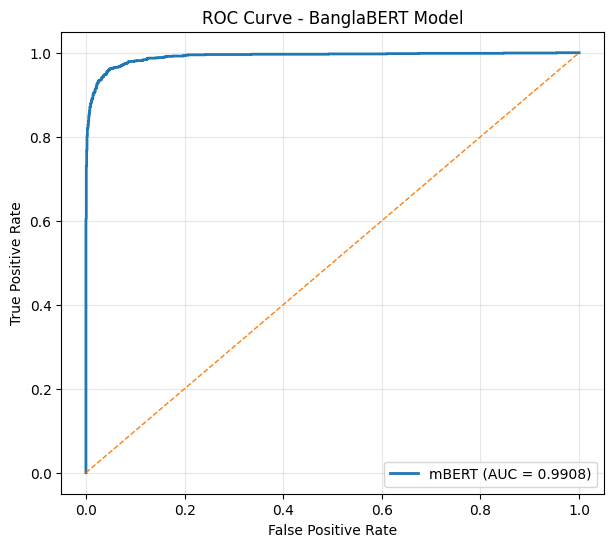

✓ ROC curve saved as 'mBERT_roc_curve.png'


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ==============================
# Get prediction probabilities
# ==============================
pred_outputs = model.predict(test_dataset)
logits = pred_outputs.logits

# Convert logits to probabilities using softmax
probs = tf.nn.softmax(logits, axis=1).numpy()

# Probability of positive class (Fake = class index 1)
y_pred_probs = probs[:, 1]

# True labels
y_true = np.array(test_labels)

# ==============================
# Compute ROC Curve
# ==============================
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

# ==============================
# Plot ROC Curve
# ==============================
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f'mBERT (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BanglaBERT Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig("mBERT_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curve saved as 'mBERT_roc_curve.png'")


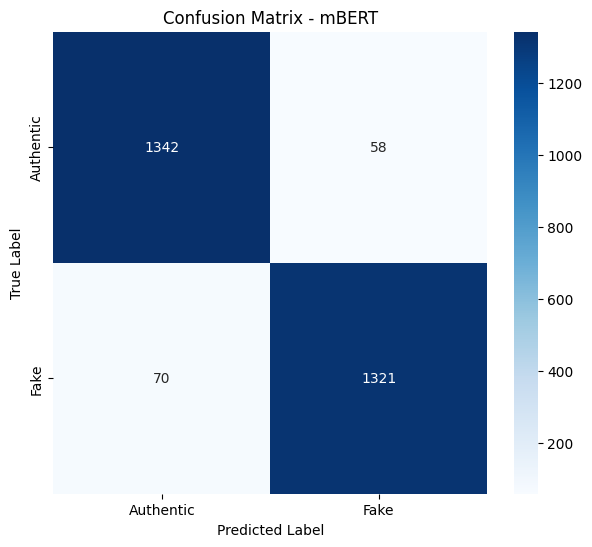

✓ Confusion matrix saved as 'banglabert_confusion_matrix.png'

Classification Report:

              precision    recall  f1-score   support

   Authentic       0.95      0.96      0.95      1400
        Fake       0.96      0.95      0.95      1391

    accuracy                           0.95      2791
   macro avg       0.95      0.95      0.95      2791
weighted avg       0.95      0.95      0.95      2791



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
# y_true = np.array(test_labels)

# # Predicted class labels
# pred_outputs = model.predict(test_dataset)
# y_pred = np.argmax(pred_outputs.logits, axis=1)

# ==============================
# Confusion Matrix
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Fake'],
            yticklabels=['Authentic', 'Fake'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - mBERT")
plt.savefig("mBERT_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved as 'banglabert_confusion_matrix.png'")

# ==============================
# Classification Report
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Authentic', 'Fake']))
